Faces loaded: 19


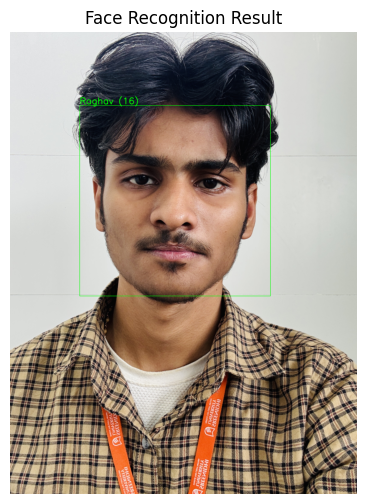

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt   # ✅ added

# 1. Face Detection
def detect_face(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_alt.xml'
    )

    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5)

    if len(faces) == 0:
        return None, None

    (x, y, w, h) = faces[0]
    return gray[y:y+h, x:x+w], faces[0]


# 2. Prepare Training Data
def prepare_training_data(data_folder_path):
    if not os.path.exists(data_folder_path):
        print(f"Error: The directory '{data_folder_path}' does not exist.")
        return [], []

    dirs = os.listdir(data_folder_path)
    faces = []
    labels = []

    for dir_name in dirs:
        if not dir_name.startswith("s"):
            continue

        label = int(dir_name.replace("s", ""))
        subject_dir_path = os.path.join(data_folder_path, dir_name)
        subject_images_names = os.listdir(subject_dir_path)

        for image_name in subject_images_names:
            image_path = os.path.join(subject_dir_path, image_name)
            image = cv2.imread(image_path)

            if image is None:
                continue

            face, rect = detect_face(image)
            if face is not None:
                faces.append(face)
                labels.append(label)

    return faces, labels


# 3. Training
DATASET_PATH = "training_data"

faces, labels = prepare_training_data(DATASET_PATH)

if len(faces) == 0:
    print("No training data found.")
else:
    print(f"Faces loaded: {len(faces)}")

    face_recognizer = cv2.face.LBPHFaceRecognizer_create()
    face_recognizer.train(faces, np.array(labels))

    subjects = ["", "Raghav", "Karthik"]

    test_image_path = "raghav.jpg"
    img = cv2.imread(test_image_path)

    if img is not None:
        face, rect = detect_face(img)

        if face is not None:
            label, confidence = face_recognizer.predict(face)
            label_text = subjects[label] if label < len(subjects) else "Unknown"

            (x, y, w, h) = rect
            cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(img, f"{label_text} ({int(confidence)})",
            (x, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,   # better font
            2.0,                        # bigger scale
            (0, 255, 0),
            3,                          # thicker stroke
            cv2.LINE_AA)

            # 🔥 Convert BGR → RGB for matplotlib
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # 🔥 Show using matplotlib
            plt.figure(figsize=(6, 6))
            plt.imshow(img_rgb)
            plt.axis("off")
            plt.title("Face Recognition Result")
            plt.show()

        else:
            print("No face detected in test image.")

    else:
        print("Test image not found.")